In [1]:
import numpy as np
import scipy.ndimage as nd
from skimage import data, morphology, filters as imfilter
import cv2
import matplotlib.pyplot as plt
import skimage.metrics as metrics
cv2.useOptimized()
import urllib.request

Original Image Shape: (512, 768, 3)


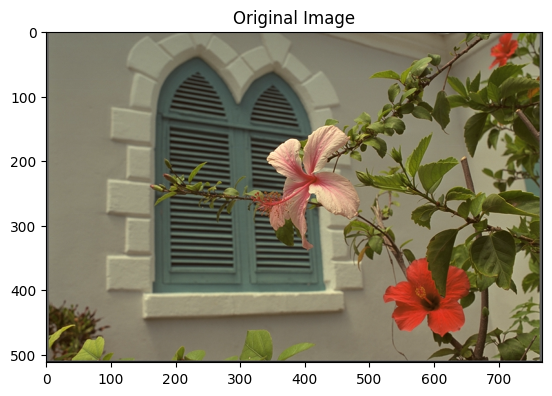

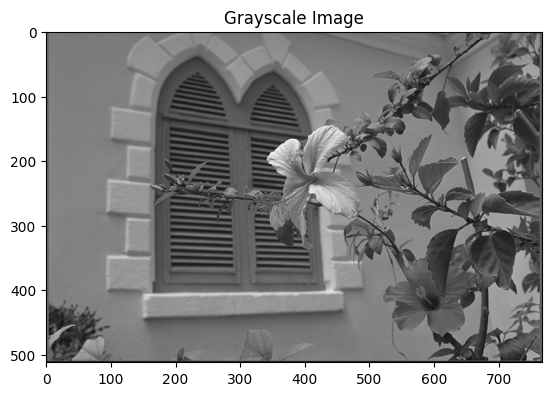

In [ ]:
# read samle image from url
urllib.request.urlretrieve('https://r0k.us/graphics/kodak/kodak/kodim07.png', 'kodim07.png')
im=cv2.imread('kodim07.png')
im=cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
imgray=cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)

plt.figure()
plt.imshow(im)
plt.title('Original Image')

plt.figure()
plt.imshow(imgray, cmap='gray')
plt.title('Grayscale Image')


Max frequency at:  256 384


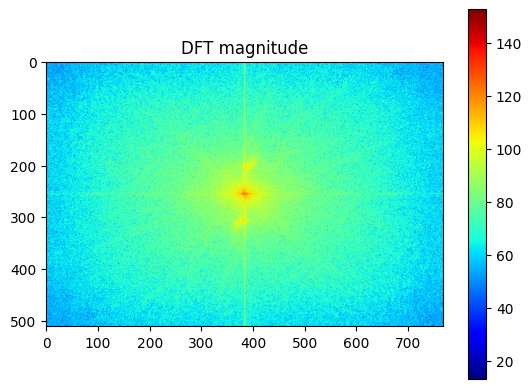

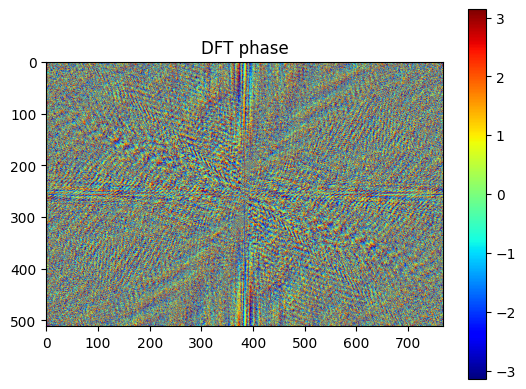

In [3]:
#compute dft
#dft = cv2.dft(np.float32(imgray),flags = cv2.DFT_COMPLEX_OUTPUT)

dft = np.fft.fft2(imgray)
dft_shift = np.fft.fftshift(dft)



plt.figure()
#plt.imshow(20*np.log10(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1])), cmap='gray')
plt.imshow(20*np.log10(np.abs(dft_shift)), cmap='jet')
plt.colorbar()
plt.title('DFT magnitude')


plt.figure()
#plt.imshow(20*np.log10(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1])), cmap='gray')
plt.imshow(np.angle(dft_shift), cmap='jet')
plt.colorbar()
plt.title('DFT phase')

# find the maxmum frequency
rows, cols = imgray.shape
m = np.argmax(np.abs(dft_shift.flatten()), axis=0)
print('Max frequency at: ',m//cols,m%cols)

(1, 768)
(512, 1)


Text(0.5, 1.0, 'DFT')

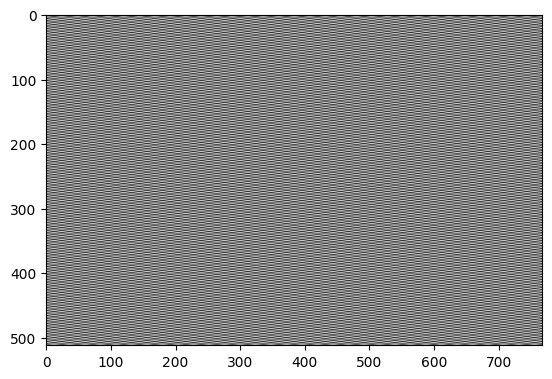

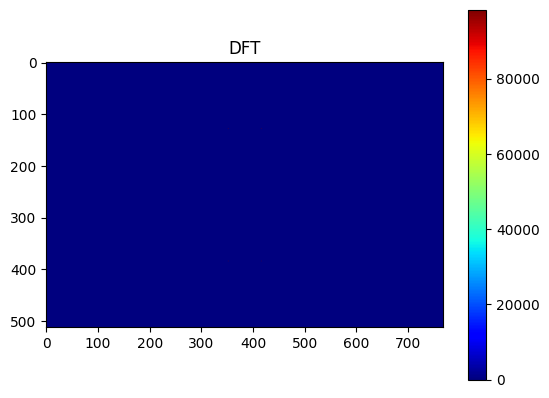

In [6]:
#create a sinusoidal pattern

rows, cols = imgray.shape
w0=np.pi/12
nc=np.arange(0,cols)
row_img=np.cos(w0*nc).reshape(1,cols)
print(row_img.shape)


w1=np.pi/2
#w1=0
nr=np.arange(0,rows)
col_img=np.cos(w1*nr).reshape(rows,1)
print(col_img.shape)

sinusoidal_img=col_img@row_img
plt.figure()
plt.imshow(sinusoidal_img*255, cmap='gray')

dft = np.fft.fft2(sinusoidal_img)
dft_shift = np.fft.fftshift(dft)

plt.figure()
#plt.imshow(np.log10(np.abs(dft_shift)+0.00000001), cmap='gray')
plt.imshow(np.abs(dft_shift), cmap='jet')
plt.colorbar()
plt.title('DFT')

Now use DFT to analyze the response of some filters

[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
[[1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]]


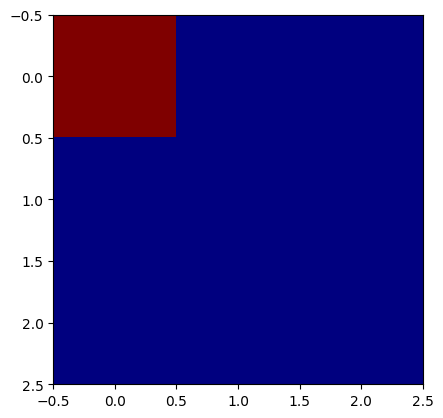

In [ ]:
average_filter = np.ones((3,3))/9
dft = np.fft.fft2(average_filter)

print(average_filter)
print(dft)

plt.figure()
# Fourier transform of the average filter
plt.imshow(np.log10(np.abs(dft)+0.00000001), cmap='jet')

Text(0.5, 0.92, 'DFT of 3x3 average filter')

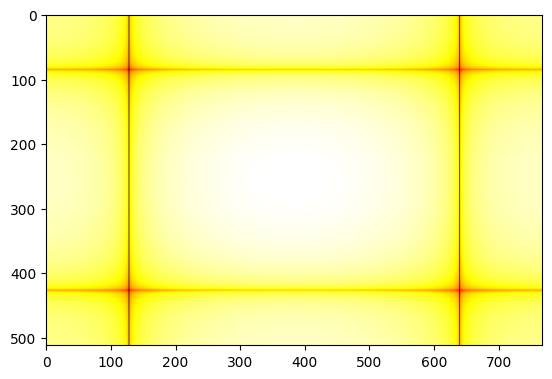

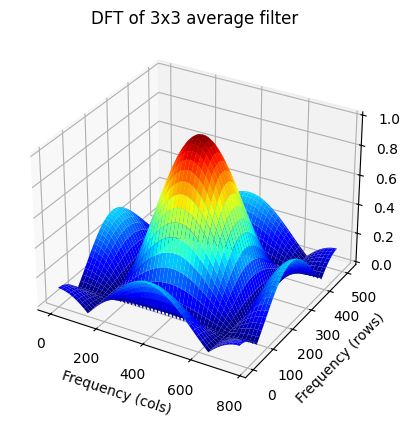

In [8]:
average_filter = np.ones((3,3))/9
rows, cols = imgray.shape
rows=512
cols=768
dft = np.fft.fft2(average_filter, s=(rows,cols))
dft=np.fft.fftshift(dft)

plt.figure()
plt.imshow(np.log10(np.abs(dft)+0.00000001), cmap='hot')


#show dft as a 3d plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x = np.arange(0, cols, 1)
y = np.arange(0, rows, 1)
X, Y = np.meshgrid(x, y)
Z = np.abs(dft) #np.log10(np.abs(dft)+0.00000001)
ax.plot_surface(X, Y, Z, cmap='jet')
plt.xlabel('Frequency (cols)')
plt.ylabel('Frequency (rows)')
plt.title('DFT of 3x3 average filter')

Text(0.5, 0.92, 'DFT of Laplacian filter')

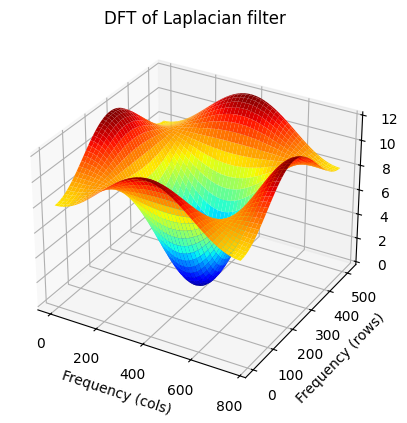

In [9]:
lapl=np.array([[1,1,1],[1,-8,1],[1,1,1]])
dft = np.fft.fft2(lapl, s=(rows,cols))
dft=np.fft.fftshift(dft)

#show dft as a 3d plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x = np.arange(0, cols, 1)
y = np.arange(0, rows, 1)
X, Y = np.meshgrid(x, y)
Z = np.abs(dft) #np.log10(np.abs(dft)+0.00000001)
ax.plot_surface(X, Y, Z, cmap='jet')
plt.xlabel('Frequency (cols)')
plt.ylabel('Frequency (rows)')
plt.title('DFT of Laplacian filter')


In [11]:
#function to compute a Gaussian filter in DFT domain
def gaussian_filter_response(rows, cols, sigma):
    cx=rows//2
    cy=cols//2
    x = np.arange(0, cols)
    y = np.arange(0, rows)
    X, Y = np.meshgrid(x, y)
    G = np.exp(-(((X-cx)**2 + (Y-cy)**2)/(2*sigma**2)))
    return G

def gaussian_filter_dft(im,sigma=1):
    rows, cols = im.shape
    G=gaussian_filter_response(rows, cols, sigma)


    # fig=plt.figure()
    # ax = fig.add_subplot(111, projection='3d')
    # x = np.arange(0, cols, 1)
    # y = np.arange(0, rows, 1)
    # X, Y = np.meshgrid(x, y)
    # ax.plot_surface(X, Y, G, cmap='jet')
    # plt.show()
    #plt.imshow(G,cmap='hot')
    G=np.fft.fftshift(G) #restore dft domain with DC in (0,0)



    dftI=np.fft.fft2(im)
    filtered_dftI=dftI*G
    filtered_im=np.abs(np.fft.ifft2(filtered_dftI))
    return filtered_im

Text(0.5, 1.0, 'Gaussian filtered')

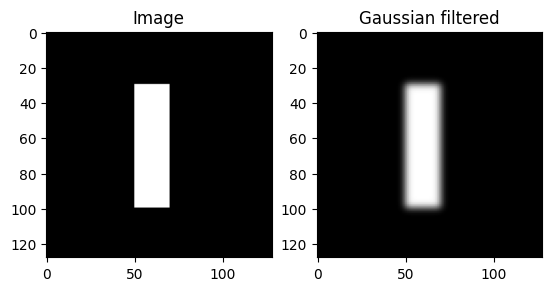

In [12]:
img=np.zeros((128,128))
img[30:100,50:70]=127
filtered=gaussian_filter_dft(img,10)


plt.figure()
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Image')

plt.subplot(1,2,2)
plt.imshow(filtered,cmap='gray')
plt.title('Gaussian filtered')

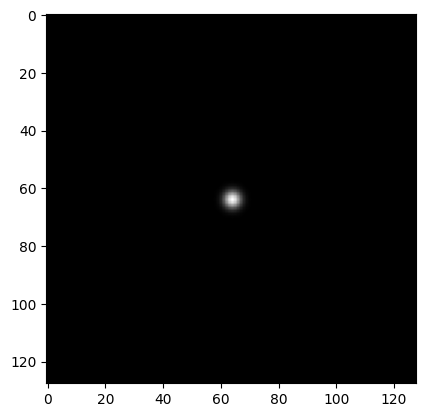

In [13]:
G=gaussian_filter_response(128, 128, 10)
G=np.fft.fftshift(G)
h=np.fft.ifft2(G)

plt.figure()
plt.imshow(np.abs(np.fft.fftshift(h)),cmap='gray')